In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.data.DataLoader import DataLoader
from src.data.Elastic import Elastic

In [6]:
elastic_connection = Elastic(timeout=5)
dataloader = DataLoader(
    elastic_client=elastic_connection,
    index='lexical'
)

raw_df = dataloader.df
n = len(raw_df)
n

149565

In [3]:
X = dataloader.df.drop(['url', 'type'], axis=1, inplace=False)
y = dataloader.df['type']

<Axes: >

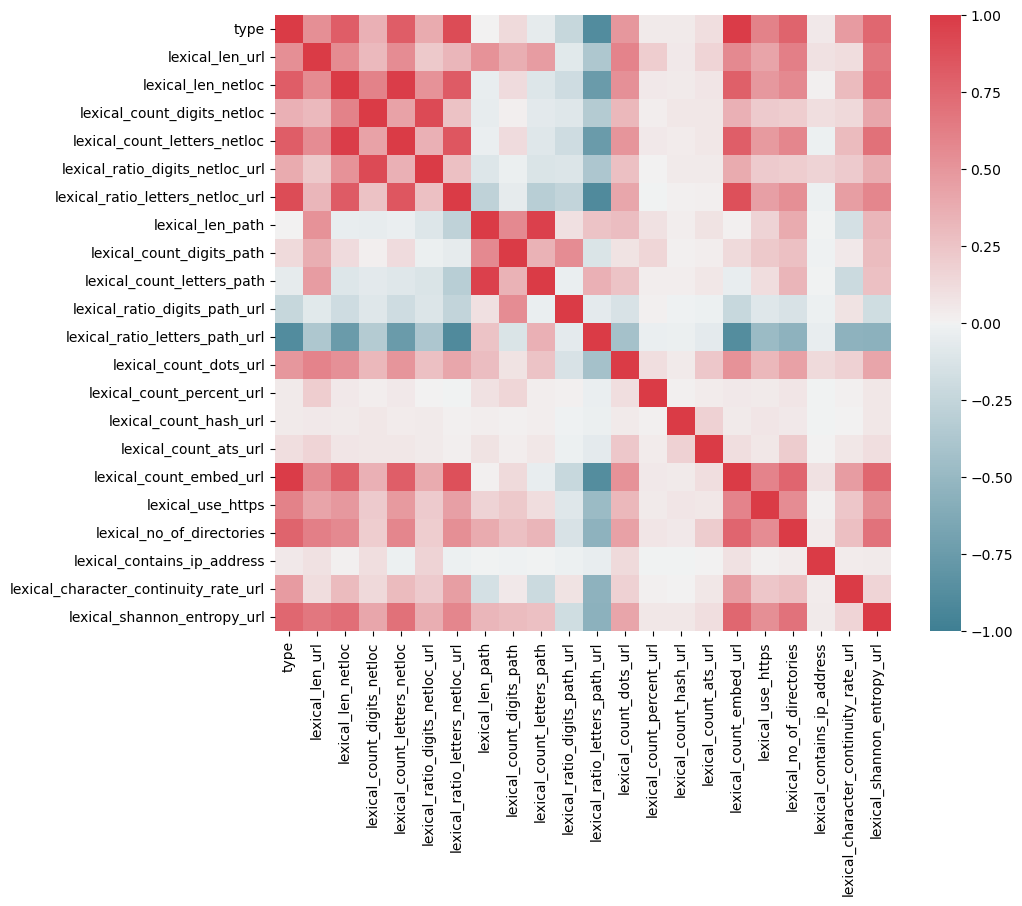

In [7]:
f, ax = plt.subplots(figsize=(10, 8))
corr = raw_df.corr()
sns.heatmap(corr,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True, ax=ax)

In [4]:
# display first 5 data points
raw_df.head(5)

,url,type,lexical_len_url,lexical_len_netloc,lexical_count_digits_netloc,lexical_count_letters_netloc,lexical_ratio_digits_netloc_url,lexical_ratio_letters_netloc_url,lexical_len_path,lexical_count_digits_path,lexical_count_letters_path,lexical_ratio_digits_path_url,lexical_ratio_letters_path_url,lexical_count_dots_url,lexical_count_percent_url,lexical_count_hash_url,lexical_count_ats_url,lexical_count_embed_url,lexical_use_https,lexical_no_of_directories,lexical_contains_ip_address,lexical_character_continuity_rate_url,lexical_shannon_entropy_url
0,https://tender.zigmaglobal.in/fiilll/korea.html,1,47,21,0,19,0.000000,0.404255,18,0,15,0.000000,0.319149,3,0,0,0,1,1,2,0,0.085106,4.155133
1,https://americanas.ltd/,1,23,14,0,13,0.000000,0.565217,1,0,0,0.000000,0.000000,1,0,0,0,1,1,1,0,0.086957,3.816403
2,https://wordpress-1234555-4409640.cloudwaysapp...,1,83,43,14,25,0.168675,0.301205,32,2,24,0.024096,0.289157,3,0,0,0,1,1,4,0,0.072289,4.755526
3,http://dana-kagetx-2024.pakaidana.my.id/,1,40,32,4,23,0.100000,0.575000,1,0,0,0.000000,0.000000,3,0,0,0,1,0,1,0,0.050000,4.055152
4,https://prestashop-166464-0.cloudclusters.net/,1,46,37,7,26,0.152174,0.565217,1,0,0,0.000000,0.000000,2,0,0,0,1,1,1,0,0.065217,4.214022


In [ ]:
# display last 5 data points
raw_df.tail(5)

In [5]:
# display general dataset info
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 149565 entries, 0 to 9564
Data columns (total 23 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   url                                    149565 non-null  object 
 1   type                                   149565 non-null  int64  
 2   lexical_len_url                        149565 non-null  int64  
 3   lexical_len_netloc                     149565 non-null  int64  
 4   lexical_count_digits_netloc            149565 non-null  int64  
 5   lexical_count_letters_netloc           149565 non-null  int64  
 6   lexical_ratio_digits_netloc_url        149565 non-null  float64
 7   lexical_ratio_letters_netloc_url       149565 non-null  float64
 8   lexical_len_path                       149565 non-null  int64  
 9   lexical_count_digits_path              149565 non-null  int64  
 10  lexical_count_letters_path             149565 non-null  in

In [6]:
# count duplicates
raw_df.groupby(raw_df.columns.tolist(),as_index=False).size()

,url,type,lexical_len_url,lexical_len_netloc,lexical_count_digits_netloc,lexical_count_letters_netloc,lexical_ratio_digits_netloc_url,lexical_ratio_letters_netloc_url,lexical_len_path,lexical_count_digits_path,lexical_count_letters_path,lexical_ratio_digits_path_url,lexical_ratio_letters_path_url,lexical_count_dots_url,lexical_count_percent_url,lexical_count_hash_url,lexical_count_ats_url,lexical_count_embed_url,lexical_use_https,lexical_no_of_directories,lexical_contains_ip_address,lexical_character_continuity_rate_url,lexical_shannon_entropy_url,size
0,0-0-0.com,0,9,0,0,0,0.000000,0.000000,9,3,3,0.333333,0.333333,1,0,0,0,0,0,0,0,0.000000,2.419382,1
1,0-0.online,0,10,0,0,0,0.000000,0.000000,10,2,6,0.200000,0.600000,1,0,0,0,0,0,0,0,0.000000,2.921928,1
2,0-02.net,0,8,0,0,0,0.000000,0.000000,8,3,3,0.375000,0.375000,1,0,0,0,0,0,0,0,0.000000,2.750000,1
3,0-070.com,0,9,0,0,0,0.000000,0.000000,9,4,3,0.444444,0.333333,1,0,0,0,0,0,0,0,0.000000,2.641604,1
4,0-1-1-0.site,0,12,0,0,0,0.000000,0.000000,12,4,4,0.333333,0.333333,1,0,0,0,0,0,0,0,0.000000,2.855389,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149560,https://zxvlinks.pages.dev/,1,27,18,0,16,0.000000,0.592593,1,0,0,0.000000,0.000000,2,0,0,0,1,1,1,0,0.074074,4.032303,1
149561,https://zy3cv1wnm4-1324839608.cos.ap-shanghai-...,1,90,54,13,34,0.144444,0.377778,16,3,11,0.033333,0.122222,6,0,0,1,1,1,1,0,0.022222,4.939766,1
149562,https://zy4sa.badp4r.biz.id/,1,28,19,2,14,0.071429,0.500000,1,0,0,0.000000,0.000000,3,0,0,0,1,1,1,0,0.071429,3.824863,1
149563,https://zyh780914.vip/,1,22,13,6,6,0.272727,0.272727,1,0,0,0.000000,0.000000,1,0,0,0,1,1,1,0,0.090909,3.970573,1


In [7]:
# identify number of null values
raw_df.isnull().sum()

url                                      0
type                                     0
lexical_len_url                          0
lexical_len_netloc                       0
lexical_count_digits_netloc              0
lexical_count_letters_netloc             0
lexical_ratio_digits_netloc_url          0
lexical_ratio_letters_netloc_url         0
lexical_len_path                         0
lexical_count_digits_path                0
lexical_count_letters_path               0
lexical_ratio_digits_path_url            0
lexical_ratio_letters_path_url           0
lexical_count_dots_url                   0
lexical_count_percent_url                0
lexical_count_hash_url                   0
lexical_count_ats_url                    0
lexical_count_embed_url                  0
lexical_use_https                        0
lexical_no_of_directories                0
lexical_contains_ip_address              0
lexical_character_continuity_rate_url    0
lexical_shannon_entropy_url              0
dtype: int6

In [8]:
# display number of uniques
raw_df.nunique()

url                                      149565
type                                          2
lexical_len_url                             456
lexical_len_netloc                           92
lexical_count_digits_netloc                  52
lexical_count_letters_netloc                 77
lexical_ratio_digits_netloc_url            1292
lexical_ratio_letters_netloc_url           2563
lexical_len_path                            241
lexical_count_digits_path                    80
lexical_count_letters_path                  212
lexical_ratio_digits_path_url              1577
lexical_ratio_letters_path_url             2814
lexical_count_dots_url                       58
lexical_count_percent_url                    25
lexical_count_hash_url                        3
lexical_count_ats_url                         7
lexical_count_embed_url                       8
lexical_use_https                             2
lexical_no_of_directories                    19
lexical_contains_ip_address             

In [13]:
# stastical analysis
raw_df.describe().T

,count,unique,top,freq
url,147170,113001,https://realizesolucaofinanceira.ngrok.app/log...,3
type,147170,2,1,83734
domain,95526,60950,CF-IPFS.COM,3365
domain_length,95526,57,2.0,28462
name_servers,89753,28989,"JOBS.NS.CLOUDFLARE.COM, MEERA.NS.CLOUDFLARE.CO...",3365
TLD,95345,419,COM,45912
registrar,88804,1696,"GoDaddy.com, LLC",11596
whois_server,70992,518,whois.godaddy.com,10512
creation_date,73474,40862,"12/05/2018, 16:31:16",3365
expiration_date,73353,37332,"12/05/2032, 16:31:16",3365


In [22]:
dup_url = raw_df[raw_df.duplicated('url')]
dup_url

,url,type,domain,domain_length,name_servers,TLD,registrar,whois_server,creation_date,expiration_date,updated_date,dnssec,len_url,len_component,count_digits_component,count_letters_component,ratio_digits_component_url,ratio_letters_component_url,count_dots_url,count_percent_url,count_hash_url,count_ats_url,count_embed_url,use_https,no_of_directories,contains_ip_address,character_continuity_rate_url,shannon_entropy_url,redirects,len_html,len_text,len_links,len_mail_usage_forms,meta_script_link_percentage,mouseover_changes,right_click_disabled,keyboard_shortcuts_disabled,copy_paste_disabled,drag_drop_disabled,popup_window_has_text_field,use_iframe,use_upload,use_download,use_http_link
50,https://storrior.info/cute/pss/jsnmaeezixukdxo...,1,storrior.info,13.0,"ns27.domaincontrol.com, ns28.domaincontrol.com",info,"GoDaddy.com, LLC",whois.godaddy.com/,"03/13/2015, 19:03:44","03/13/2025, 19:03:44",NaN,NaN,260,239,35,199,0.1346153846153846,0.7653846153846153,1,0,0,0,1,1,4,0,0.03461538461538462,5.181630547439695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,https://storrior.info/cute/pss/08hutxomn1vphty...,1,storrior.info,13.0,"ns27.domaincontrol.com, ns28.domaincontrol.com",info,"GoDaddy.com, LLC",whois.godaddy.com/,"03/13/2015, 19:03:44","03/13/2025, 19:03:44",NaN,NaN,260,239,34,200,0.13076923076923078,0.7692307692307693,1,0,0,0,1,1,4,0,0.038461538461538464,5.183780262906171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,https://storrior.info/cute/pss/pfrnsmhhod8lxwt...,1,storrior.info,13.0,"ns27.domaincontrol.com, ns28.domaincontrol.com",info,"GoDaddy.com, LLC",whois.godaddy.com/,"03/13/2015, 19:03:44","03/13/2025, 19:03:44",NaN,NaN,264,243,22,217,0.08333333333333333,0.821969696969697,1,0,0,0,1,1,4,0,0.026515151515151516,5.673009011177652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,https://storrior.info/cute/pss/fua3tsvea87lqvx...,1,storrior.info,13.0,"ns27.domaincontrol.com, ns28.domaincontrol.com",info,"GoDaddy.com, LLC",whois.godaddy.com/,"03/13/2015, 19:03:44","03/13/2025, 19:03:44",NaN,NaN,268,247,29,213,0.10820895522388059,0.7947761194029851,1,0,0,0,1,1,4,0,0.033582089552238806,5.236453968934295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
194,https://storrior.info/cute/pss/boyyecgxikmxlec...,1,storrior.info,13.0,"ns27.domaincontrol.com, ns28.domaincontrol.com",info,"GoDaddy.com, LLC",whois.godaddy.com/,"03/13/2015, 19:03:44","03/13/2025, 19:03:44",NaN,NaN,822,253,29,217,0.03527980535279805,0.2639902676399027,7,0,0,0,3,1,5,0,0.043795620437956206,5.281147911671707,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,http://hnhrr.weebly.com/,1,WEEBLY.COM,10.0,"DNS1.P01.NSONE.NET, DNS2.P01.NSONE.NET, DNS3.P...",COM,Safenames Ltd,whois.safenames.net,"03/29/2006, 00:25:07","03/28/2025, 23:25:07",NaN,unsigned,24,1,0,0,0.0,0.0,2,0,0,0,1,0,1,0,0.16666666666666666,3.8553885422075336,1.0,36372.0,433.0,7.0,0.0,"0.0, 0.6190476190476191, 0.38095238095238093",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1166,http://junofree.pages.dev/,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26,1,0,0,0.0,0.0,2,0,0,0,1,0,1,0,0.11538461538461539,3.979097891134805,1.0,218265.0,1219.0,25.0,0.0,"0.0, 0.0, 1.0",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1167,http://wgbht.blogspot.ug/,1,wgbht.blogspot.ug,17.0,NaN,ug,NaN,NaN,NaN,NaN,NaN,NaN,25,1,0,0,0.0,0.0,2,0,0,0,1,0,1,0,0.08,3.543465189601647,2.0,71430.0,326.0,7.0,0.0,"0.0, 0.3333333333333333, 0.6666666666666666",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1168,http://40f9x6ap.duckdns.org/,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28,1,0,0,0.0,0.0,2,0,0,0,1,0,1,0,0.07142857142857142,4.351823225551766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
tdf = raw_df.copy(deep=True)

In [32]:
tdf.drop_duplicates(subset=['url'], keep='first')

,url,type,domain,domain_length,name_servers,TLD,registrar,whois_server,creation_date,expiration_date,updated_date,dnssec,len_url,len_component,count_digits_component,count_letters_component,ratio_digits_component_url,ratio_letters_component_url,count_dots_url,count_percent_url,count_hash_url,count_ats_url,count_embed_url,use_https,no_of_directories,contains_ip_address,character_continuity_rate_url,shannon_entropy_url,redirects,len_html,len_text,len_links,len_mail_usage_forms,meta_script_link_percentage,mouseover_changes,right_click_disabled,keyboard_shortcuts_disabled,copy_paste_disabled,drag_drop_disabled,popup_window_has_text_field,use_iframe,use_upload,use_download,use_http_link
0,a1-systems.com,0,A1-SYSTEMS.COM,14.0,"NS1.A1-SYSTEMS.COM, NS2.A1-SYSTEMS.COM, NS3.A1...",COM,"Regional Network Information Center, JSC dba R...",whois.nic.ru,"12/30/2002, 05:23:46",NaN,"02/21/2024, 08:10:39| 02/21/2024, 08:10:38",signedDelegation,14,14,1,11,0.07142857142857142,0.7857142857142857,1,0,0,0,0,0,0,0,0.0,3.3248629576173565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a1.art,0,A1.ART,6.0,"NS-1033.AWSDNS-01.ORG, NS-1933.AWSDNS-49.CO.UK...",ART,"Go Daddy, LLC",whois.godaddy.com,"09/16/2023, 14:24:05","09/16/2028, 23:59:59",NaN,unsigned,6,6,1,4,0.16666666666666666,0.6666666666666666,1,0,0,0,0,0,0,0,0.0,2.2516291673878226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a1.at,0,a1.at,5.0,NaN,at,A1 Telekom Austria AG ( https://nic.at/registr...,NaN,NaN,NaN,"09/24/2019, 10:24:18| 06/27/2018, 09:53:49| 06...",NaN,5,5,1,3,0.2,0.6,1,0,0,0,0,0,0,0,0.0,1.9219280948873623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,a1.bg,0,a1.bg (a1.bg),13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,5,1,3,0.2,0.6,1,0,0,0,0,0,0,0,0.0,2.321928094887362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,a1.by,0,a1.by,5.0,"ns1.a1.by, ns2.a1.by, ns3.a1.by, ns4.a1.by",by,"Reliable Software, Ltd",NaN,"08/11/2008, 00:00:00","04/16/2026, 00:00:00",NaN,NaN,5,5,1,3,0.2,0.6,1,0,0,0,0,0,0,0,0.0,2.321928094887362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9165,amgload.net,0,AMGLOAD.NET,11.0,"NS15.ABOVEDOMAINS.COM, NS16.ABOVEDOMAINS.COM",NET,"Free Spirit Domains, LLC",whois.web.com,"02/21/2022, 19:26:01","02/21/2025, 19:26:01",NaN,unsigned,11,11,0,10,0.0,0.9090909090909091,1,0,0,0,0,0,0,0,0.0,3.2776134368191157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9166,amgoldman.com,0,AMGOLDMAN.COM,13.0,"NS71.DOMAINCONTROL.COM, NS72.DOMAINCONTROL.COM",COM,"GoDaddy.com, LLC",whois.godaddy.com,NaN,NaN,"02/21/2024, 11:21:33| 02/21/2024, 06:21:31",unsigned,13,13,0,12,0.0,0.9230769230769231,1,0,0,0,0,0,0,0,0.0,3.0269868333592873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9167,amgradio.ru,0,AMGRADIO.RU,11.0,"ns1.mcs.mail.ru., ns2.mcs.mail.ru.",RU,REGRU-RU,NaN,"01/21/2020, 08:26:54","01/21/2025, 08:26:54",NaN,NaN,11,11,0,10,0.0,0.9090909090909091,1,0,0,0,0,0,0,0,0.0,3.095795255000934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9168,amgreatness.com,0,"['AMGREATNESS.COM', 'amgreatness.com']",2.0,"NS-1483.AWSDNS-57.ORG, NS-1634.AWSDNS-12.CO.UK...",COM,IONOS SE,whois.ionos.com,"06/29/2016, 06:38:41","06/29/2024, 06:38:41",NaN,"['unsigned', 'Unsigned']",15,15,0,14,0.0,0.9333333333333333,1,0,0,0,0,0,0,0,0.06666666666666667,3.3735572622751855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
def is_float(element):
    try:
        float(element)
        return True
    except ValueError:
        return False
    
for col in tdf.select_dtypes(include='object').columns:
    # Test if the column can be converted to integers
    if tdf[col].apply(lambda x: str(x).isdigit()).all():
        tdf[col] = tdf[col].astype(int)
    # Test if the column can be converted to floats
    elif tdf[col].apply(lambda x: is_float(x)).all():
        tdf[col] = tdf[col].astype(float)
    # Otherwise, leave it as object (string)
    

In [37]:
cat_cols = tdf.select_dtypes(include=['object']).columns
num_cols = tdf.select_dtypes(include=np.number).columns.tolist()

print(f"Categorical Variables: {cat_cols}")
print(f"Numerical Variables:{num_cols}")

Categorical Variables: Index(['url', 'domain', 'name_servers', 'TLD', 'registrar', 'whois_server',
       'creation_date', 'expiration_date', 'updated_date', 'dnssec',
       'meta_script_link_percentage'],
      dtype='object')
Numerical Variables:['type', 'domain_length', 'len_url', 'len_component', 'count_digits_component', 'count_letters_component', 'ratio_digits_component_url', 'ratio_letters_component_url', 'count_dots_url', 'count_percent_url', 'count_hash_url', 'count_ats_url', 'count_embed_url', 'use_https', 'no_of_directories', 'contains_ip_address', 'character_continuity_rate_url', 'shannon_entropy_url', 'redirects', 'len_html', 'len_text', 'len_links', 'len_mail_usage_forms', 'mouseover_changes', 'right_click_disabled', 'keyboard_shortcuts_disabled', 'copy_paste_disabled', 'drag_drop_disabled', 'popup_window_has_text_field', 'use_iframe', 'use_upload', 'use_download', 'use_http_link']


In [39]:
tdf['meta_script_link_percentage']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
9165    NaN
9166    NaN
9167    NaN
9168    NaN
9169    NaN
Name: meta_script_link_percentage, Length: 149170, dtype: object

In [ ]:
for col in num_cols:
    print(col)
    print('Skew :', round(raw_df[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    raw_df[col].hist(grid=False)
    plt.ylabel('Count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=raw_df[col])
    plt.show()

In [ ]:
drop = ['url']

plt.figure(figsize=(36, 36), dpi = 480)
sns.heatmap(raw_df.drop(drop, axis=1).corr(), annot = True, vmin = -1, vmax = 1, fmt='.2f')
plt.show()